# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

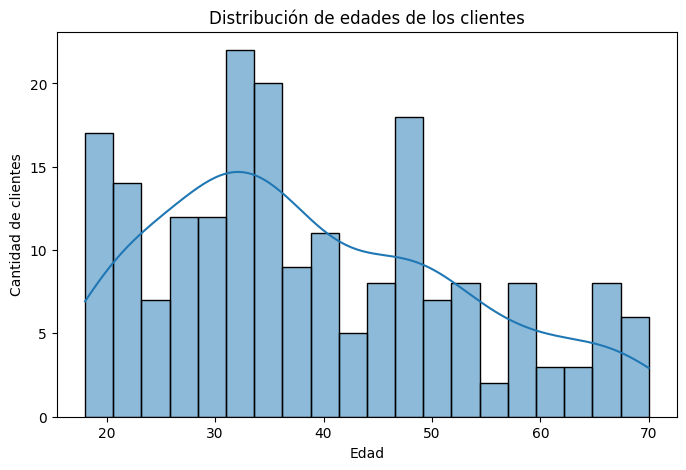

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Distribución de edades de los clientes")
plt.xlabel("Edad")
plt.ylabel("Cantidad de clientes")

plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

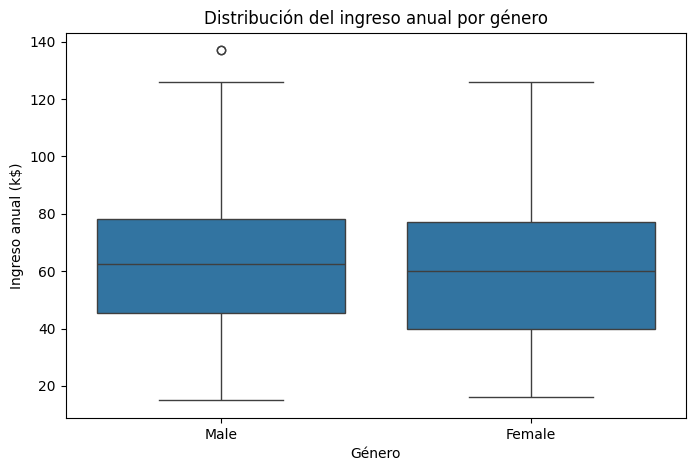

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Annual Income (k$)"
)

plt.title("Distribución del ingreso anual por género")
plt.xlabel("Género")
plt.ylabel("Ingreso anual (k$)")

plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

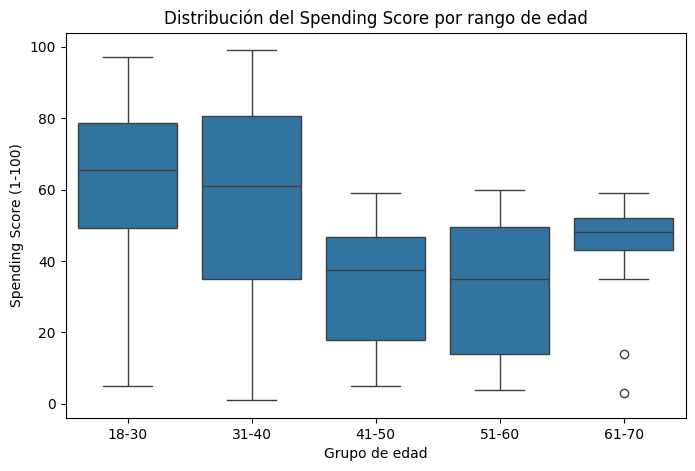

In [12]:
# Crear grupos de edad
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,60,70],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70"
    ]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Age_Group",
    y="Spending Score (1-100)"
)

plt.title("Distribución del Spending Score por rango de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Spending Score (1-100)")

plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

                        Annual Income (k$)  Spending Score (1-100)
Annual Income (k$)                1.000000                0.009903
Spending Score (1-100)            0.009903                1.000000


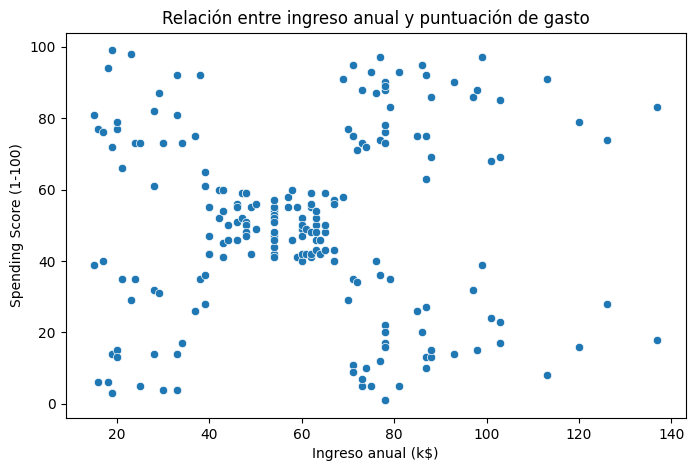

In [13]:
# Calcular correlación
correlation = df[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].corr()

print(correlation)


# Gráfica de dispersión
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Relación entre ingreso anual y puntuación de gasto")
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

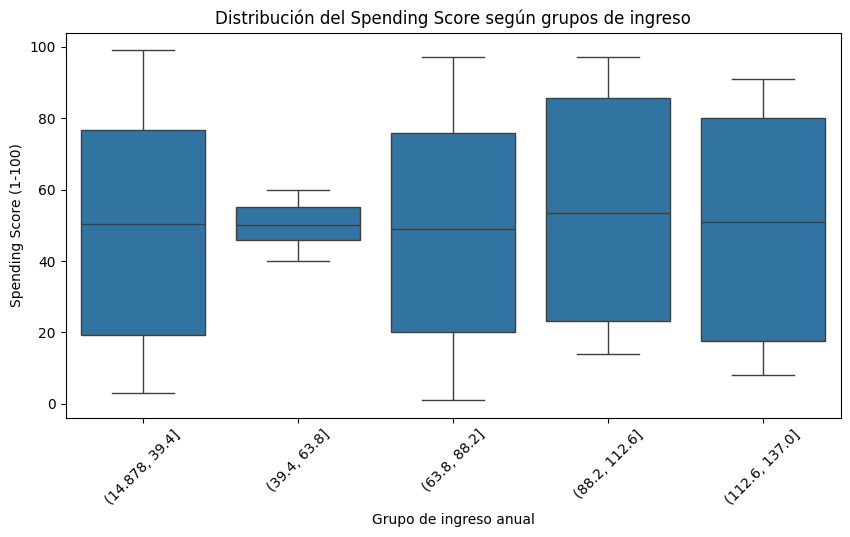

In [14]:
# Crear grupos de ingreso
df['Income_Group'] = pd.cut(
    df['Annual Income (k$)'],
    bins=5
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Income_Group",
    y="Spending Score (1-100)"
)

plt.xticks(rotation=45)

plt.title("Distribución del Spending Score según grupos de ingreso")
plt.xlabel("Grupo de ingreso anual")
plt.ylabel("Spending Score (1-100)")

plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

Gender
Female    112
Male       88
Name: count, dtype: int64


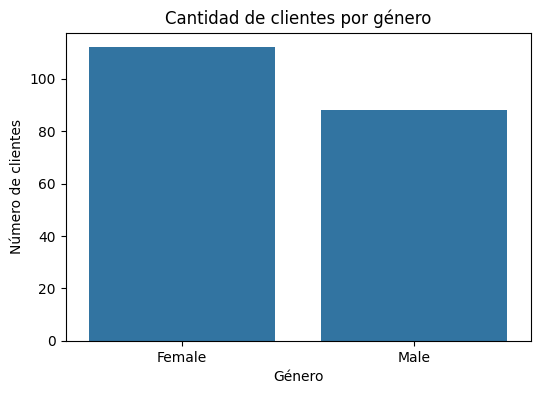

In [15]:
# Contar clientes por género
gender_count = df['Gender'].value_counts()

print(gender_count)


# Gráfica de barras
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_count.index,
    y=gender_count.values
)

plt.title("Cantidad de clientes por género")
plt.xlabel("Género")
plt.ylabel("Número de clientes")

plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

Age_Group
18-30    61.103448
31-40    57.500000
41-50    34.394737
51-60    32.521739
61-70    44.176471
Name: Spending Score (1-100), dtype: float64


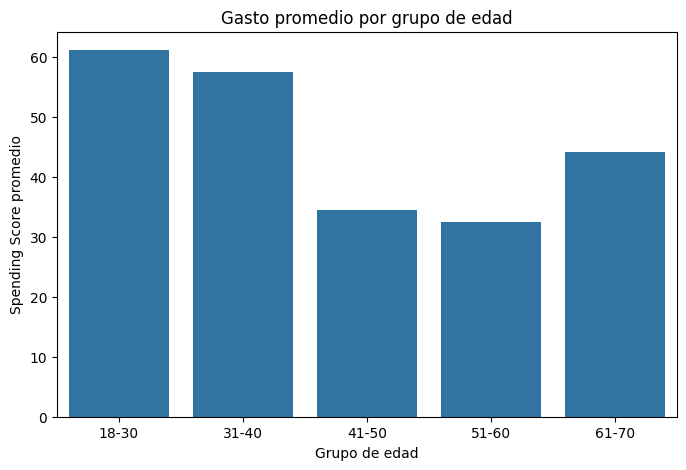

In [16]:
# Calcular gasto promedio por grupo de edad
age_spending = df.groupby(
    'Age_Group',
    observed=True
)['Spending Score (1-100)'].mean()

print(age_spending)


# Gráfica de barras
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_spending.index,
    y=age_spending.values
)

plt.title("Gasto promedio por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Spending Score promedio")

plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

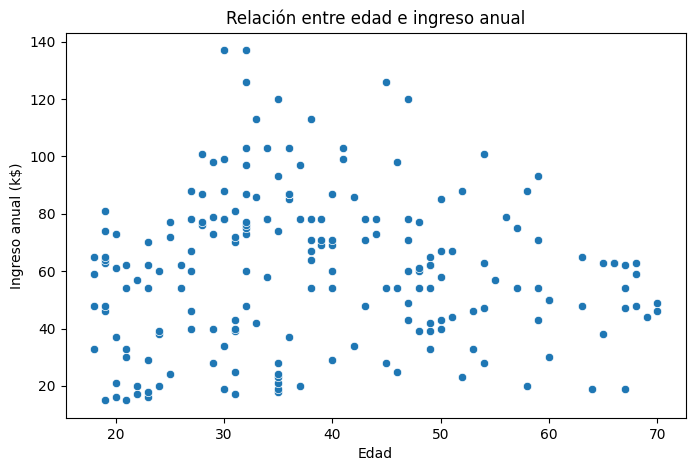

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Annual Income (k$)"
)

plt.title("Relación entre edad e ingreso anual")
plt.xlabel("Edad")
plt.ylabel("Ingreso anual (k$)")

plt.show()

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

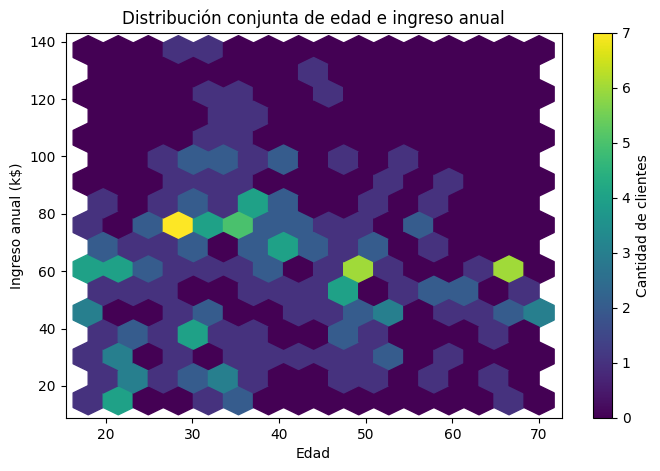

In [18]:
plt.figure(figsize=(8,5))

plt.hexbin(
    df['Age'],
    df['Annual Income (k$)'],
    gridsize=15
)

plt.colorbar(
    label="Cantidad de clientes"
)

plt.xlabel("Edad")
plt.ylabel("Ingreso anual (k$)")

plt.title("Distribución conjunta de edad e ingreso anual")

plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

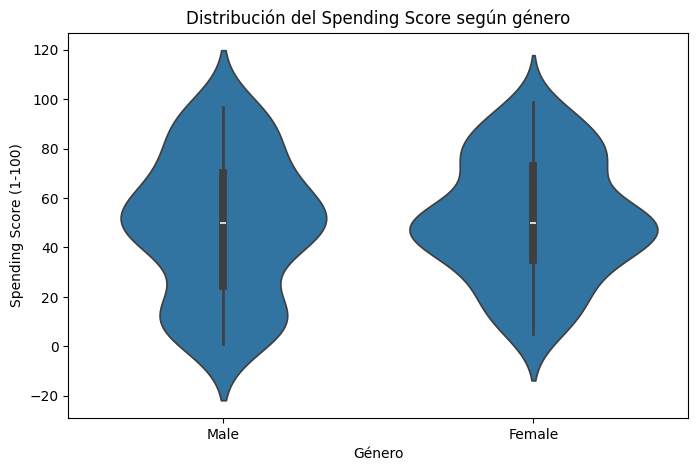

In [19]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)"
)

plt.title("Distribución del Spending Score según género")
plt.xlabel("Género")
plt.ylabel("Spending Score (1-100)")

plt.show()



In [8]:
df = pd.read_csv("retailmax.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')